# Momentum factors — `qufin.analysis.momentum`

**Momentum** is the empirical tendency for recent winners to keep winning
and recent losers to keep losing — one of the most robust anomalies in
asset pricing, documented across equities, bonds, commodities and FX.

This package implements the two canonical constructions:

* **Time-series momentum (TSMOM)** — Moskowitz, Ooi & Pedersen (2012). Judge
  *each asset against its own past*: long if it has risen over the lookback,
  short if it has fallen, sized to a constant volatility target. An
  **absolute**, direction-bearing signal.
* **Cross-sectional momentum** — Jegadeesh & Titman (1993). Rank a *universe*
  by trailing return; long the winners, short the losers, dollar-neutral. A
  **relative** signal with little net market exposure.

**Sections**

0. Data — a small multi-asset panel (real, with synthetic fallback)
1. Trailing return — the raw momentum signal
2. Time-series momentum + volatility targeting
3. Cross-sectional momentum on the panel
4. The trainable strategy wrapper


## Why volatility targeting matters

A raw ±1 momentum signal mixes calm and turbulent assets, so the loud ones
dominate portfolio risk. **Volatility targeting** rescales each position by
``target_vol / σ̂_t`` so every position contributes roughly the same risk:

    pos_t = sign(trailing return) · min(cap, target_vol / σ̂_{t,ann})

This single step is what lets TSMOM be *pooled* across dozens of markets
into a stable trend-following portfolio, and it materially improves
risk-adjusted returns versus an unscaled signal.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from qufin.analysis import (
    trailing_return, time_series_momentum, cross_sectional_momentum,
)
from qufin.strategies import TimeSeriesMomentumStrategy, TSMOMParams

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## 0. Data

We try to pull a small basket of liquid ETFs; offline, the loader falls back
to a synthetic panel where each asset has a distinct drift so the momentum
ranking is well defined. Output is a `(T, N)` price matrix plus the tickers.


In [2]:
TICKERS = ['SPY', 'TLT', 'GLD', 'EEM', 'USO', 'HYG']

def load_panel(tickers=TICKERS, start='2010-01-01', end='2024-01-01'):
    try:
        import pandas as pd
        import yfinance as yf
        raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
        close = raw['Close'][tickers].dropna()
        if len(close) > 1000:
            return close.to_numpy(dtype='float64'), list(close.columns)
    except Exception as exc:
        print(f'yfinance unavailable ({exc!r}); using synthetic panel')
    rng = np.random.default_rng(0)
    n_t, n_a = 2500, len(tickers)
    drifts = np.linspace(-0.0004, 0.0006, n_a)
    log_p = np.cumsum(drifts + rng.normal(0.0, 0.009, size=(n_t, n_a)), axis=0)
    return 100.0 * np.exp(log_p), list(tickers)

prices, tickers = load_panel()
print(f'panel: {prices.shape[0]} rows x {prices.shape[1]} assets: {tickers}')


panel: 3522 rows x 6 assets: ['SPY', 'TLT', 'GLD', 'EEM', 'USO', 'HYG']


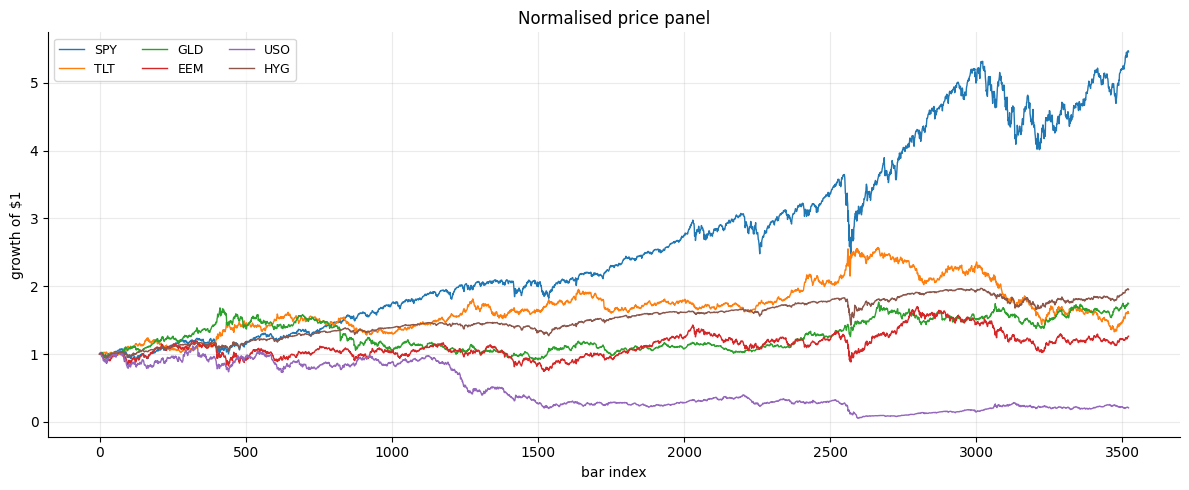

In [3]:
fig, ax = plt.subplots()
for j, tk in enumerate(tickers):
    ax.plot(prices[:, j] / prices[0, j], lw=1.0, label=tk)
ax.set_title('Normalised price panel'); ax.set_ylabel('growth of $1')
ax.set_xlabel('bar index'); ax.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.show()


## 1. Trailing return — the raw signal

Both momentum flavours start from the **trailing return** over a formation
window. Its *sign* drives TSMOM; its *cross-sectional rank* drives
Jegadeesh-Titman.


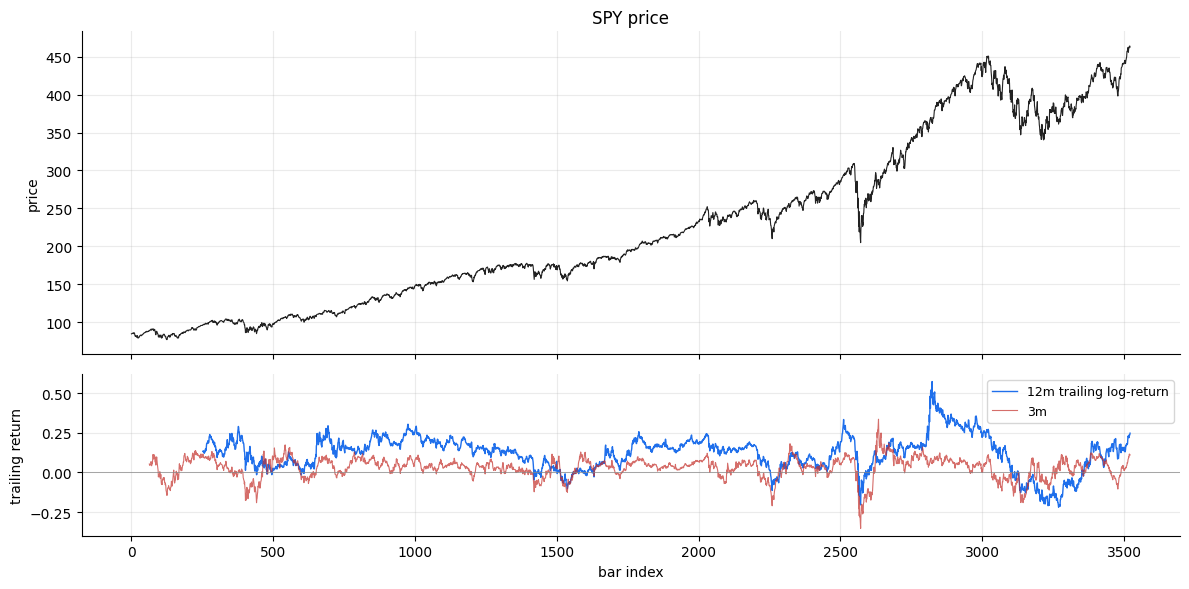

In [4]:
asset = 0
tr_12m = trailing_return(prices[:, asset], 252)
tr_3m = trailing_return(prices[:, asset], 63)

fig, (axp, axt) = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1], figsize=(12, 6))
axp.plot(prices[:, asset], color='#222', lw=0.8); axp.set_title(f'{tickers[asset]} price')
axp.set_ylabel('price')
axt.plot(tr_12m, color='#1f6feb', lw=1.0, label='12m trailing log-return')
axt.plot(tr_3m, color='#c4302b', lw=0.8, alpha=0.7, label='3m')
axt.axhline(0, color='#888', lw=0.5)
axt.set_ylabel('trailing return'); axt.set_xlabel('bar index'); axt.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 2. Time-series momentum

`time_series_momentum` returns a `MomentumFactorResult` with the trend
`signal`, the vol-targeted `weights`, and the realised `factor_returns`.
Below we plot the signal and the strategy equity curve for one asset.


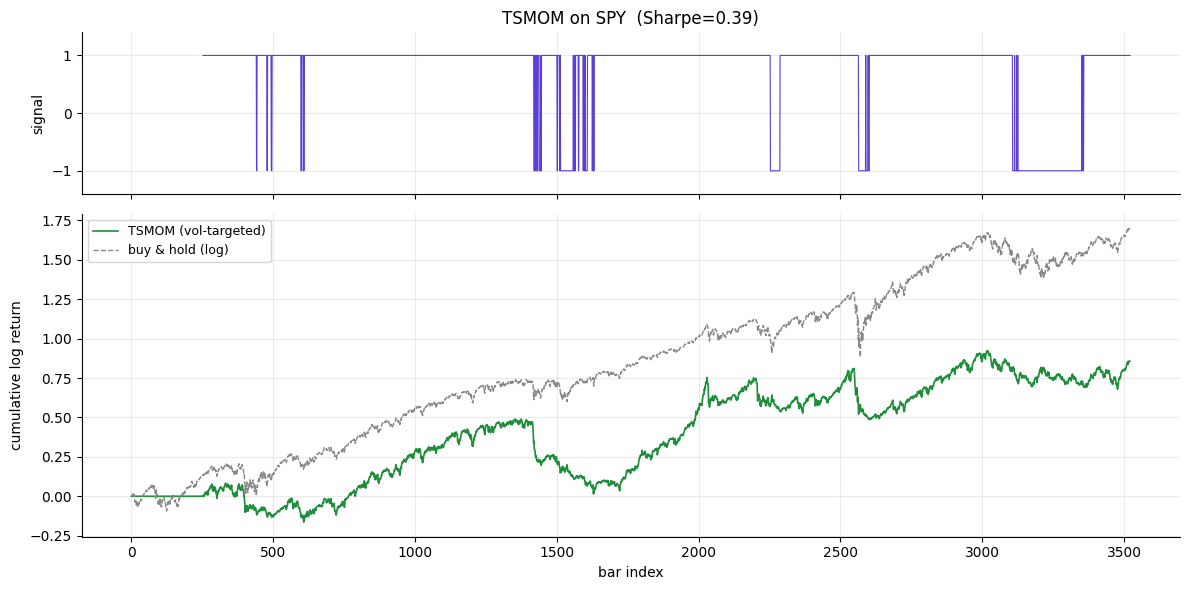

TSMOM Sharpe=0.387   cumulative=0.855


In [5]:
res = time_series_momentum(prices[:, asset], lookback=252, vol_window=60, target_vol=0.15)
equity = np.nancumsum(res.factor_returns)
buy_hold = np.cumsum(np.diff(np.log(prices[:, asset])))

fig, (axs, axe) = plt.subplots(2, 1, sharex=True, height_ratios=[1, 2], figsize=(12, 6))
axs.plot(res.signal, color='#5b3fd8', lw=0.8); axs.set_ylabel('signal'); axs.set_ylim(-1.4, 1.4)
axs.set_title(f'TSMOM on {tickers[asset]}  (Sharpe={res.sharpe:.2f})')
axe.plot(equity, color='#1f8e3a', lw=1.2, label='TSMOM (vol-targeted)')
axe.plot(buy_hold, color='#888', lw=1.0, ls='--', label='buy & hold (log)')
axe.set_ylabel('cumulative log return'); axe.set_xlabel('bar index'); axe.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f'TSMOM Sharpe={res.sharpe:.3f}   cumulative={res.cumulative_return:.3f}')


### Pooling across the panel

The power of TSMOM is **diversification**: because each leg is vol-targeted,
summing them gives a smoother portfolio than any single market.


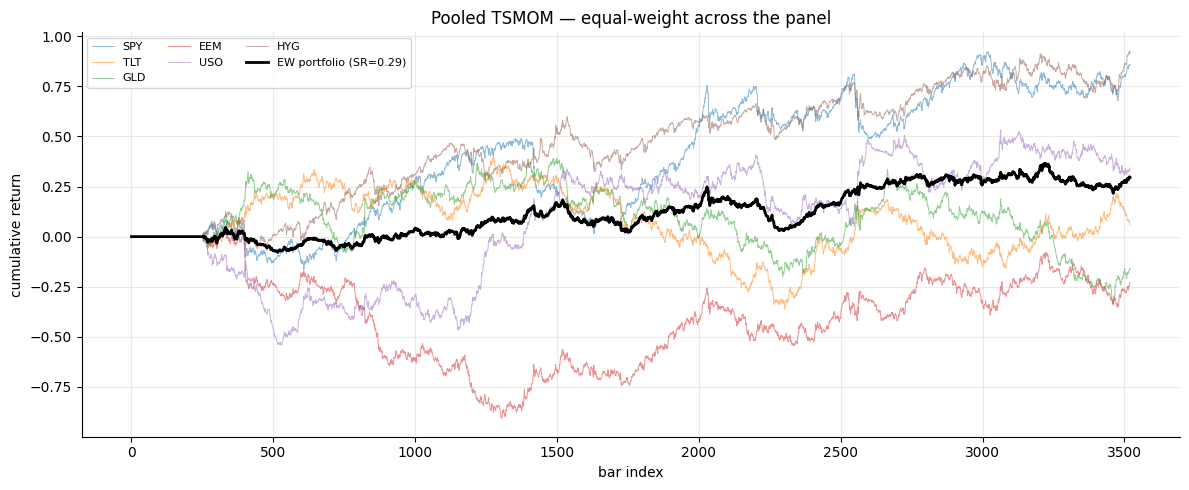

In [6]:
legs = [time_series_momentum(prices[:, j], lookback=252, vol_window=60) for j in range(len(tickers))]
portfolio = np.nanmean(np.vstack([leg.factor_returns for leg in legs]), axis=0)
port_sharpe = np.nanmean(portfolio) / np.nanstd(portfolio) * np.sqrt(252)

fig, ax = plt.subplots()
for leg, tk in zip(legs, tickers):
    ax.plot(np.nancumsum(leg.factor_returns), lw=0.7, alpha=0.5, label=tk)
ax.plot(np.nancumsum(portfolio), color='#000', lw=2.0, label=f'EW portfolio (SR={port_sharpe:.2f})')
ax.set_title('Pooled TSMOM — equal-weight across the panel')
ax.set_ylabel('cumulative return'); ax.set_xlabel('bar index'); ax.legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.show()


## 3. Cross-sectional momentum

`cross_sectional_momentum` ranks the whole panel each rebalance and forms a
dollar-neutral long-short book (top vs bottom quantile). The `skip` gap drops
the most recent bars to sidestep short-term reversal — the classic 12-1 rule.


Cross-sectional momentum: Sharpe=0.192, cumulative=0.603


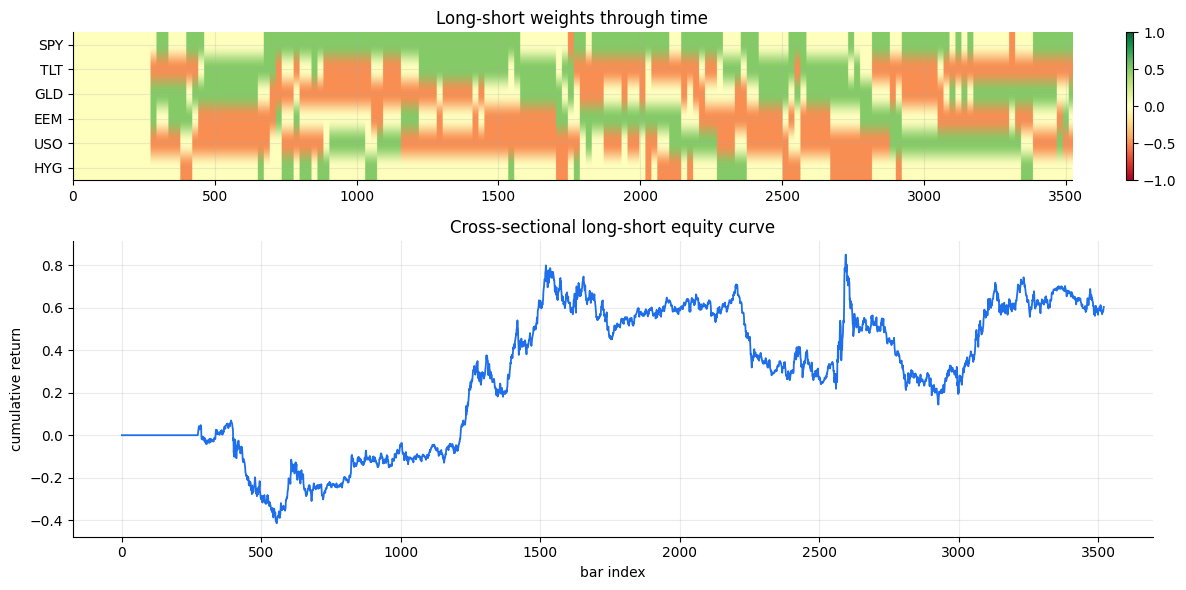

In [7]:
xs = cross_sectional_momentum(prices, lookback=252, skip=21, holding=21, n_quantiles=3)
print(f'Cross-sectional momentum: Sharpe={xs.sharpe:.3f}, cumulative={xs.cumulative_return:.3f}')

fig, (axw, axe) = plt.subplots(2, 1, height_ratios=[1, 2], figsize=(12, 6))
im = axw.imshow(xs.weights.T, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1)
axw.set_yticks(range(len(tickers))); axw.set_yticklabels(tickers)
axw.set_title('Long-short weights through time'); axw.set_xlabel('')
fig.colorbar(im, ax=axw, fraction=0.025)
axe.plot(np.nancumsum(xs.factor_returns), color='#1f6feb', lw=1.3)
axe.set_title('Cross-sectional long-short equity curve')
axe.set_ylabel('cumulative return'); axe.set_xlabel('bar index')
plt.tight_layout(); plt.show()


## 4. The trainable strategy

`TimeSeriesMomentumStrategy` wraps the factor in the standard `qufin`
strategy interface — `run` for a backtest, `fit` for an in-sample grid
search over `(lookback, vol_window, target_vol)`.


In [8]:
strat = TimeSeriesMomentumStrategy(TSMOMParams(lookback=252, vol_window=60))
print(strat.run(prices[:, asset]).summary())

train = strat.fit(prices[:, asset], lookbacks=(63, 126, 252), vol_windows=(20, 60, 120))
print(f'\nbest params: lookback={train.params.lookback}, '
      f'vol_window={train.params.vol_window}  (Sharpe={train.sharpe:.3f})')
print(strat.run(prices[:, asset]).summary())


Time-Series Momentum Summary
  Sharpe (ann.)  : 0.3868
  Total return   : 85.54%
  Max drawdown   : -47.31%
  Realised vol   : 15.83%
  Avg |position| : 1.116

best params: lookback=126, vol_window=60  (Sharpe=0.468)
Time-Series Momentum Summary
  Sharpe (ann.)  : 0.4675
  Total return   : 104.51%
  Max drawdown   : -36.59%
  Realised vol   : 16.00%
  Avg |position| : 1.147


## What next?

* **Combine the two signals.** TSMOM and cross-sectional momentum are only
  partially correlated; blending them diversifies the momentum premium.
* **Regime-gate with Hurst.** Momentum works when ``H > 0.5``; the
  `qufin.timeseries.hurst` rolling exponent is a natural on/off switch.
* **Feed the walk-forward engine.** Wrap the strategy in
  `qufin.trading.training.walk_forward` for honest out-of-sample evaluation
  instead of the in-sample grid search shown here.
* **Mind transaction costs.** Cross-sectional rebalancing turns the book
  over frequently — net the `factor_returns` against a per-turnover cost
  before trusting the Sharpe.
